In [14]:
from random_measurement import generate_povm_set_case_1,generate_povm_set_case_2
from blended_measurement import blended_measurement
from qiskit import  execute, BasicAer
import numpy as np
import matplotlib.pyplot as plt
import random
import circuit as cir


%qiskit_version_table


/tmp/ipykernel_7732/4059885709.py:3: DeprecationWarning: BasicAer is deprecated since Qiskit 0.46 and will be removed in Qiskit 1.0. The BasicAer (qiskit.providers.basicaer) module has been superseded by  qiskit.providers.basic_provider, and all its classes have been renamed to follow a new naming convention. More information and migration guidelines can be found in the 0.46 API docs for BasicAer.
  from qiskit import  execute, BasicAer


/home/jason/Documents/random_measurement/random/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jason/Documents/random_measurement/random/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


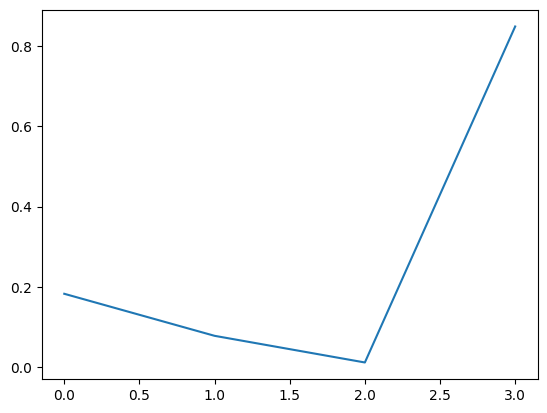

/tmp/ipykernel_7732/2563070705.py:40: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  result = execute(qc, backend, shots=num_shot).result()


{'0': 13906, '1': 2478}


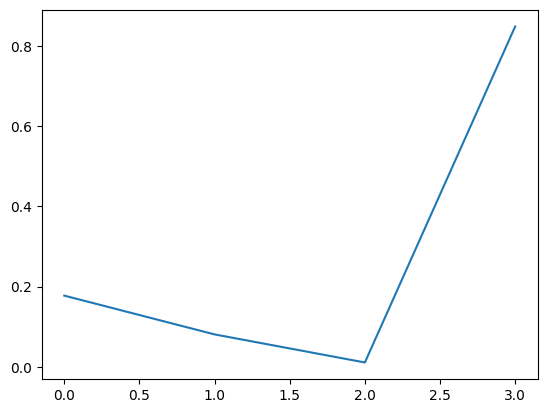

/home/jason/Documents/random_measurement/random/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


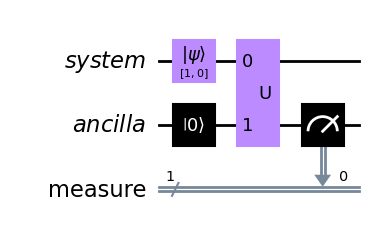

In [15]:

d = 2  # Dimension
m = 4 # Number of POVM elements

################### generate the povm measurement sets ##################################


povm_set_case_1 = generate_povm_set_case_1(d, m)
povm_set_case_2 = generate_povm_set_case_2(d, m)


################### show the povm set #################################################
povm_set_case=povm_set_case_1
pro=[]
# for item in povm_set_case:
#     eigenval,_=np.linalg.eigh(item)
#     print(eigenval)
roh_0=np.array([[1,0],[0,0]])
for item in povm_set_case:
    pro.append(np.trace(item@roh_0))
    
plt.plot(range(0,m),pro)
plt.show()


################# construct the quantum circuit #################################################

#initial state
num_shot=16384
state=np.array([[1,0]])
state = state/np.linalg.norm(state)
result_y=[]
for item in povm_set_case:
    povm=[]
    povm.append(item)
    inverse=np.eye(d)-item
    povm.append(inverse)
    qc=cir.construct_quantum_circuit(povm,state)

    backend = BasicAer.get_backend('qasm_simulator')
    result = execute(qc, backend, shots=num_shot).result()
    counts = result.get_counts(qc)
    result_y.append(counts['0'])

print(counts)
result_y=[item/num_shot for item in result_y]
plt.plot(range(0,m),result_y)
plt.show()
qc.draw('mpl') #always be put at the final line


/tmp/ipykernel_7732/2955121954.py:15: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  result = execute(qc, backend, shots=num_shot).result()


{'000': 11705, '100': 3516, '010': 350, '001': 764, '011': 49}


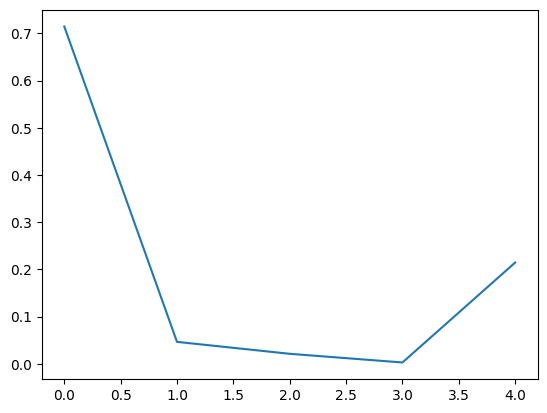

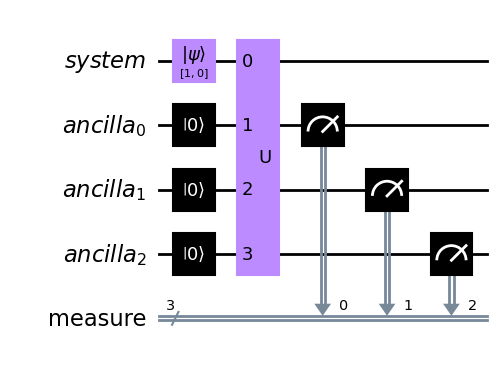

In [16]:
################## generate blended measurement sets #############################################

blended_case_1=blended_measurement(povm_set_case_1,d,m)
blended_case_2=blended_measurement(povm_set_case_2,d,m)

blended_set=blended_case_1

blended_set=[ item@item.T.conj() for item in blended_set]

# print(sum(blended_set))

qc=cir.construct_quantum_circuit(blended_set,state)

backend = BasicAer.get_backend('qasm_simulator')
result = execute(qc, backend, shots=num_shot).result()
counts = result.get_counts(qc)
print(counts)
result_y=[]

for item in sorted(counts.keys()):
    result_y.append(counts[item]/num_shot)


plt.plot(range(0,m+1),result_y)
plt.show()
qc.draw('mpl') #always be put at the final line

In [17]:
############### Blend Measurement impletement #########################

random_pick=random.randint(0,len(blended_set)-1)
